In [223]:
import pandas as pd
import torch
import numpy as np
from cgmvae import*
from torch.nn import functional as F
import matplotlib.pyplot as plt
from collections import Counter

In [131]:
# load original input data
# actually we don't really need to do this unless we're interested in accuracy of reconstruction too, but we don't necessarily need to be 
# load latent variables 
latent_features_train = pd.read_csv('/Users/racheliritani/Desktop/AD Project/mm-vae/cfc_pred/shap_analysis/train_df.csv')
latent_features_train

,LV1,LV2,LV3,LV4,LV5,mouse_ids,Diet,Mouse.ID,CFC.24mo.Average
0,1.648254,1.558364,1.450668,1.713205,1.723632,DO-1D-3168,1D,DO-1D-3168,-0.820451
1,-0.794890,-1.137012,-1.105946,-0.938151,-0.875722,DO-40-2083,40,DO-40-2083,0.780704
2,-0.348093,-0.264138,-0.208897,-0.409450,-0.600421,DO-20-1186,20,DO-20-1186,0.452638
3,0.956853,1.063802,1.653756,1.514652,1.608262,DO-1D-3059,1D,DO-1D-3059,1.698389
4,1.407127,1.454008,1.323928,1.397264,1.267337,DO-40-2002,40,DO-40-2002,-0.582971
...,...,...,...,...,...,...,...,...,...
398,-0.890301,-0.859367,-0.897388,-0.965282,-0.967811,DO-1D-3185,1D,DO-1D-3185,-1.763434
399,-0.481943,-0.825826,-0.808517,-0.631954,-0.711390,DO-2D-4058,2D,DO-2D-4058,0.951265
400,1.344620,1.542254,1.234269,1.474108,1.414498,DO-20-1053,20,DO-20-1053,-0.787807
401,0.919085,0.931402,1.518434,1.483853,1.381329,DO-20-1044,20,DO-20-1044,1.624125


In [134]:
data_with_cfc_labels = pd.read_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/data_with_cfc_5bins.csv')
data_with_cfc_labels = data_with_cfc_labels[['MouseID', 'cfc_bin']]
data_with_cfc_labels

,MouseID,cfc_bin
0,DO-40-2162,0
1,DO-40-2179,1
2,DO-40-2181,1
3,DO-40-2187,2
4,DO-40-2099,1
...,...,...
499,DO-2D-4007,1
500,DO-1D-3030,1
501,DO-20-1021,0
502,DO-AL-0002,2


In [165]:
saved_model_path = '/Users/racheliritani/Desktop/AD Project/mm-vae/results_DIET/CGMVAE_cfc_cond_5bins_5dim/saved_model_epoch5000.pth'

In [166]:
accelerator = True 

if accelerator:
    device = torch.device("mps")
else:
    device = torch.device("cpu")

In [167]:
#vae = CGMVAE()
vae = torch.load(saved_model_path, map_location=device)
vae.to(device)
vae.eval()

CGMVAE(
  (label): Embedding(5, 1)
  (fc1): Linear(in_features=37, out_features=16, bias=True)
  (bn1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc21): Linear(in_features=16, out_features=25, bias=True)
  (fc22): Linear(in_features=16, out_features=25, bias=True)
  (fc3): Linear(in_features=6, out_features=16, bias=True)
  (bn3): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc4): Linear(in_features=16, out_features=36, bias=True)
)

## Doing analysis with LV5 conditonal label 0

In [139]:
mouse_ids_0 = data_with_cfc_labels[data_with_cfc_labels['cfc_bin'] == 0]['MouseID'].tolist()
latent_features_train_0 = latent_features_train[latent_features_train['Mouse.ID'].isin(mouse_ids_0)]
latent_features_train_0 = latent_features_train_0[['LV1', 'LV2', 'LV3', 'LV4', 'LV5']]
latent_features_train_0

,LV1,LV2,LV3,LV4,LV5
13,-0.893698,-0.720176,-0.866757,-0.823112,-1.094731
14,-1.622135,-1.356036,-1.420345,-1.495535,-1.267595
23,-0.957110,-0.818695,-0.948691,-0.993643,-0.997910
25,-1.577005,-1.315113,-1.407930,-1.409376,-1.314672
30,-1.276818,-1.093347,-1.127115,-1.167925,-0.975741
...,...,...,...,...,...
388,-1.436359,-1.235382,-1.249746,-1.297314,-0.932213
389,-1.141634,-0.943330,-0.982594,-1.051950,-0.920841
390,-1.327842,-1.144189,-1.166487,-1.188210,-1.019409
394,-1.513083,-1.272883,-1.293408,-1.326203,-1.131958


In [145]:
latent_features_train_mean_0 = latent_features_train_0.mean()
latent_features_train_mean_0

LV1   -1.348009
LV2   -1.133437
LV3   -1.187552
LV4   -1.229302
LV5   -1.090288
dtype: float64

In [143]:
min(latent_features_train_0['LV5']), max(latent_features_train_0['LV5'])

(-1.320519223152376, -0.8726566010399031)

In [146]:
lv_traversal_values_0 = [-2, -1.5, -1, -0.5, 0]
latent_features_train_neg2_0 = latent_features_train_mean_0.copy()
latent_features_train_neg2_0.iloc[4] = lv_traversal_values_0[0]
latent_features_train_neg1_0 = latent_features_train_mean_0.copy()
latent_features_train_neg1_0.iloc[4] = lv_traversal_values_0[1]
latent_features_train_zero_0 = latent_features_train_mean_0.copy()
latent_features_train_zero_0.iloc[4] = lv_traversal_values_0[2]
latent_features_train_one_0 = latent_features_train_mean_0.copy()
latent_features_train_one_0.iloc[4] = lv_traversal_values_0[3]
latent_features_train_two_0 = latent_features_train_mean_0.copy()
latent_features_train_two_0.iloc[4] = lv_traversal_values_0[4]

In [150]:
stacked_data_input_0 = np.vstack((latent_features_train_neg2_0, latent_features_train_neg1_0, latent_features_train_zero_0, latent_features_train_one_0, latent_features_train_two_0))
stacked_data_input_0

array([[-1.34800858, -1.13343743, -1.18755181, -1.22930228, -2.        ],
       [-1.34800858, -1.13343743, -1.18755181, -1.22930228, -1.5       ],
       [-1.34800858, -1.13343743, -1.18755181, -1.22930228, -1.        ],
       [-1.34800858, -1.13343743, -1.18755181, -1.22930228, -0.5       ],
       [-1.34800858, -1.13343743, -1.18755181, -1.22930228,  0.        ]])

In [152]:
z_traversal_0 = torch.tensor(stacked_data_input_0, dtype=torch.float32).to(device)
#y_labels = torch.tensor(np.ones(5), dtype=torch.long).to(device)
y_labels_0 = torch.tensor(np.zeros(5), dtype=torch.long).to(device)

## Prepare data for transversing LV5 with conditional label 1

In [168]:
mouse_ids_1 = data_with_cfc_labels[data_with_cfc_labels['cfc_bin'] == 1]['MouseID'].tolist()
latent_features_train_1 = latent_features_train[latent_features_train['Mouse.ID'].isin(mouse_ids_1)]
latent_features_train_1 = latent_features_train_1[['LV1', 'LV2', 'LV3', 'LV4', 'LV5']]
latent_features_train_1

,LV1,LV2,LV3,LV4,LV5
0,1.648254,1.558364,1.450668,1.713205,1.723632
4,1.407127,1.454008,1.323928,1.397264,1.267337
15,1.219892,0.858839,0.811899,0.836143,0.712234
19,1.642225,1.663701,1.346894,1.761315,1.741227
21,1.510944,1.577664,1.146596,1.492334,1.343644
...,...,...,...,...,...
385,1.290042,1.164315,0.996189,1.291856,1.241618
387,1.512038,1.343424,1.239869,1.575708,1.555214
393,1.460973,1.360372,1.296377,1.578111,1.540010
400,1.344620,1.542254,1.234269,1.474108,1.414498


In [170]:
latent_features_train_mean_1 = latent_features_train_1.mean()
latent_features_train_mean_1

LV1    1.338759
LV2    1.337852
LV3    1.042993
LV4    1.238350
LV5    1.175304
dtype: float64

In [171]:
min(latent_features_train_1['LV5']), max(latent_features_train_1['LV5'])

(0.0255870342795916, 1.851924216054936)

In [172]:
lv_traversal_values_1 = [0, 0.5, 1, 1.5, 2]
latent_features_train_neg2_1 = latent_features_train_mean_1.copy()
latent_features_train_neg2_1.iloc[4] = lv_traversal_values_1[0]
latent_features_train_neg1_1 = latent_features_train_mean_1.copy()
latent_features_train_neg1_1.iloc[4] = lv_traversal_values_1[1]
latent_features_train_zero_1 = latent_features_train_mean_1.copy()
latent_features_train_zero_1.iloc[4] = lv_traversal_values_1[2]
latent_features_train_one_1 = latent_features_train_mean_1.copy()
latent_features_train_one_1.iloc[4] = lv_traversal_values_1[3]
latent_features_train_two_1 = latent_features_train_mean_1.copy()
latent_features_train_two_1.iloc[4] = lv_traversal_values_1[4]

In [173]:
stacked_data_input_1 = np.vstack((latent_features_train_neg2_1, latent_features_train_neg1_1, latent_features_train_zero_1, latent_features_train_one_1, latent_features_train_two_1))
stacked_data_input_1

array([[1.33875905, 1.33785187, 1.04299338, 1.23834988, 0.        ],
       [1.33875905, 1.33785187, 1.04299338, 1.23834988, 0.5       ],
       [1.33875905, 1.33785187, 1.04299338, 1.23834988, 1.        ],
       [1.33875905, 1.33785187, 1.04299338, 1.23834988, 1.5       ],
       [1.33875905, 1.33785187, 1.04299338, 1.23834988, 2.        ]])

In [174]:
z_traversal_1 = torch.tensor(stacked_data_input_1, dtype=torch.float32).to(device)
y_labels_1 = torch.tensor(np.ones(5), dtype=torch.long).to(device)

# Prepare data for traversing LV5 with conditional label 2

In [187]:
mouse_ids_2 = data_with_cfc_labels[data_with_cfc_labels['cfc_bin'] == 2]['MouseID'].tolist()
latent_features_train_2 = latent_features_train[latent_features_train['Mouse.ID'].isin(mouse_ids_2)]
latent_features_train_2 = latent_features_train_2[['LV1', 'LV2', 'LV3', 'LV4', 'LV5']]
latent_features_train_2

,LV1,LV2,LV3,LV4,LV5
2,-0.348093,-0.264138,-0.208897,-0.409450,-0.600421
5,0.035996,0.163485,0.447772,0.348364,0.387066
7,0.014778,-0.089215,0.067121,-0.068191,-0.177578
10,-0.055891,-0.020498,0.081582,-0.034955,-0.152137
11,0.142019,0.236467,0.418668,0.282368,0.217389
...,...,...,...,...,...
370,-0.149577,-0.281372,-0.351628,-0.525232,-0.632906
380,-0.082595,-0.111938,0.116845,-0.013294,0.003919
382,-0.117836,-0.044868,-0.031371,-0.131411,-0.181905
395,-0.126171,-0.197896,-0.105915,-0.251575,-0.388558


In [188]:
latent_features_train_mean_2 = latent_features_train_2.mean()
latent_features_train_mean_2

LV1   -0.110642
LV2   -0.064196
LV3    0.047799
LV4   -0.086370
LV5   -0.156310
dtype: float64

In [189]:
min(latent_features_train_2['LV5']), max(latent_features_train_2['LV5'])

(-0.8867416537216524, 0.8221739980775844)

In [190]:
lv_traversal_values_2 = [-1, -0.5, 0, 0.5, 1]
latent_features_train_neg2_2 = latent_features_train_mean_2.copy()
latent_features_train_neg2_2.iloc[4] = lv_traversal_values_2[0]
latent_features_train_neg1_2 = latent_features_train_mean_2.copy()
latent_features_train_neg1_2.iloc[4] = lv_traversal_values_2[1]
latent_features_train_zero_2 = latent_features_train_mean_2.copy()
latent_features_train_zero_2.iloc[4] = lv_traversal_values_2[2]
latent_features_train_one_2 = latent_features_train_mean_2.copy()
latent_features_train_one_2.iloc[4] = lv_traversal_values_2[3]
latent_features_train_two_2 = latent_features_train_mean_2.copy()
latent_features_train_two_2.iloc[4] = lv_traversal_values_2[4]

In [191]:
stacked_data_input_2 = np.vstack((latent_features_train_neg2_2, latent_features_train_neg1_2, latent_features_train_zero_2, latent_features_train_one_2, latent_features_train_two_2))
stacked_data_input_2

array([[-0.11064207, -0.06419645,  0.0477987 , -0.08637038, -1.        ],
       [-0.11064207, -0.06419645,  0.0477987 , -0.08637038, -0.5       ],
       [-0.11064207, -0.06419645,  0.0477987 , -0.08637038,  0.        ],
       [-0.11064207, -0.06419645,  0.0477987 , -0.08637038,  0.5       ],
       [-0.11064207, -0.06419645,  0.0477987 , -0.08637038,  1.        ]])

In [193]:
z_traversal_2 = torch.tensor(stacked_data_input_2, dtype=torch.float32).to(device)
y_labels_2 = torch.tensor(np.ones(5) * 2, dtype=torch.long).to(device)

# Prepare data for traversing LV5 with conditional label 3

In [199]:
mouse_ids_3 = data_with_cfc_labels[data_with_cfc_labels['cfc_bin'] == 3]['MouseID'].tolist()
latent_features_train_3 = latent_features_train[latent_features_train['Mouse.ID'].isin(mouse_ids_3)]
latent_features_train_3 = latent_features_train_3[['LV1', 'LV2', 'LV3', 'LV4', 'LV5']]
latent_features_train_3

,LV1,LV2,LV3,LV4,LV5
1,-0.794890,-1.137012,-1.105946,-0.938151,-0.875722
6,-0.577949,-0.922756,-0.905568,-0.737581,-0.774369
8,-0.475260,-0.876369,-0.796801,-0.632104,-0.687762
16,-0.541115,-0.852015,-0.859629,-0.709350,-0.757850
26,-0.231526,-0.615353,-0.641229,-0.464054,-0.702358
...,...,...,...,...,...
377,-0.056066,-0.411063,-0.400782,-0.268354,-0.583646
379,-0.888835,-1.038130,-1.258650,-1.086238,-1.199128
386,-0.406040,-0.840978,-0.788157,-0.581329,-0.696034
397,-0.521439,-0.892044,-0.884971,-0.669015,-0.744653


In [200]:
latent_features_train_mean_3 = latent_features_train_3.mean()
latent_features_train_mean_3

LV1   -0.560520
LV2   -0.896860
LV3   -0.899536
LV4   -0.714436
LV5   -0.797925
dtype: float64

In [201]:
min(latent_features_train_3['LV5']), max(latent_features_train_3['LV5'])

(-1.199157765776946, -0.5333699880575999)

In [202]:
lv_traversal_values_3 = [-2, -1.5, -1, -0.5, 0]
latent_features_train_neg2_3 = latent_features_train_mean_3.copy()
latent_features_train_neg2_3.iloc[4] = lv_traversal_values_3[0]
latent_features_train_neg1_3 = latent_features_train_mean_3.copy()
latent_features_train_neg1_3.iloc[4] = lv_traversal_values_3[1]
latent_features_train_zero_3 = latent_features_train_mean_3.copy()
latent_features_train_zero_3.iloc[4] = lv_traversal_values_3[2]
latent_features_train_one_3 = latent_features_train_mean_3.copy()
latent_features_train_one_3.iloc[4] = lv_traversal_values_3[3]
latent_features_train_two_3 = latent_features_train_mean_3.copy()
latent_features_train_two_3.iloc[4] = lv_traversal_values_3[4]

In [203]:
stacked_data_input_3 = np.vstack((latent_features_train_neg2_3, latent_features_train_neg1_3, latent_features_train_zero_3, latent_features_train_one_3, latent_features_train_two_3))
stacked_data_input_3

array([[-0.56051965, -0.89686036, -0.89953568, -0.71443556, -2.        ],
       [-0.56051965, -0.89686036, -0.89953568, -0.71443556, -1.5       ],
       [-0.56051965, -0.89686036, -0.89953568, -0.71443556, -1.        ],
       [-0.56051965, -0.89686036, -0.89953568, -0.71443556, -0.5       ],
       [-0.56051965, -0.89686036, -0.89953568, -0.71443556,  0.        ]])

In [205]:
z_traversal_3 = torch.tensor(stacked_data_input_3, dtype=torch.float32).to(device)
y_labels_3 = torch.tensor(np.ones(5) * 3, dtype=torch.long).to(device)

# Prepare data for traversing LV5 with conditional label 4

In [207]:
mouse_ids_4 = data_with_cfc_labels[data_with_cfc_labels['cfc_bin'] == 4]['MouseID'].tolist()
latent_features_train_4 = latent_features_train[latent_features_train['Mouse.ID'].isin(mouse_ids_4)]
latent_features_train_4 = latent_features_train_4[['LV1', 'LV2', 'LV3', 'LV4', 'LV5']]

In [208]:
latent_features_train_mean_4 = latent_features_train_4.mean()
latent_features_train_mean_4

LV1    0.930291
LV2    1.044031
LV3    1.538322
LV4    1.168438
LV5    1.401014
dtype: float64

In [209]:
min(latent_features_train_4['LV5']), max(latent_features_train_4['LV5'])

(0.4395141894613483, 1.7969646274984823)

In [210]:
lv_traversal_values_4 = [0, 0.5, 1, 1.5, 2]
latent_features_train_neg2_4 = latent_features_train_mean_4.copy()
latent_features_train_neg2_4.iloc[4] = lv_traversal_values_4[0]
latent_features_train_neg1_4 = latent_features_train_mean_4.copy()
latent_features_train_neg1_4.iloc[4] = lv_traversal_values_4[1]
latent_features_train_zero_4 = latent_features_train_mean_4.copy()
latent_features_train_zero_4.iloc[4] = lv_traversal_values_4[2]
latent_features_train_one_4 = latent_features_train_mean_4.copy()
latent_features_train_one_4.iloc[4] = lv_traversal_values_4[3]
latent_features_train_two_4 = latent_features_train_mean_4.copy()
latent_features_train_two_4.iloc[4] = lv_traversal_values_4[4]

In [211]:
stacked_data_input_4 = np.vstack((latent_features_train_neg2_4, latent_features_train_neg1_4, latent_features_train_zero_4, latent_features_train_one_4, latent_features_train_two_4))
stacked_data_input_4

array([[0.93029123, 1.0440314 , 1.53832194, 1.16843782, 0.        ],
       [0.93029123, 1.0440314 , 1.53832194, 1.16843782, 0.5       ],
       [0.93029123, 1.0440314 , 1.53832194, 1.16843782, 1.        ],
       [0.93029123, 1.0440314 , 1.53832194, 1.16843782, 1.5       ],
       [0.93029123, 1.0440314 , 1.53832194, 1.16843782, 2.        ]])

In [212]:
z_traversal_4 = torch.tensor(stacked_data_input_4, dtype=torch.float32).to(device)
y_labels_4 = torch.tensor(np.ones(5) * 4, dtype=torch.long).to(device)

# Get mean and std for unstandardizing 

In [175]:
# Using training data to extract the mean and standardizing for our "unstandardizing"
cgmvae_train_data = pd.read_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/train_data_with_cfc_5bins.csv')
cgmvae_train_data_features = cgmvae_train_data.iloc[:, 1:-5]
cgmvae_train_data_features

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,28,1557,30.432753,23.594599,23.529931,161.043852,71.901384,69.226421,495.841743,501.256947,...,1.822722,0.348339,0.747802,291.910043,181.741358,208.833723,0.183285,0.231782,0.235033,1
1,28,1520,25.977819,29.254446,30.242503,127.747193,85.358891,71.148922,466.210754,464.586935,...,0.999795,1.146192,0.924488,145.679543,223.139358,208.833223,0.106295,0.174654,0.216059,1
2,26,1638,24.242912,23.626717,22.912834,166.520150,72.692867,59.960123,464.789558,574.873297,...,1.044482,1.776962,2.179152,261.760471,173.953709,153.357082,0.110173,0.155822,0.285573,1
3,28,1406,24.467278,25.248257,23.109300,164.713839,87.471495,73.518078,467.014292,562.596065,...,1.680998,0.523920,0.894472,172.757669,113.888445,116.420115,0.104875,0.186652,0.231596,1
4,27,1463,27.809766,25.863157,26.732366,158.296170,79.935074,89.493029,460.859469,452.538921,...,1.255751,1.035345,0.902079,232.284376,238.633857,250.015922,0.106669,0.199779,0.104132,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
398,22,825,26.553743,38.871831,38.162515,88.072095,132.803099,261.476515,457.706405,636.333799,...,1.327876,-0.250994,-2.736010,144.637287,200.397753,58.352082,0.301015,0.221042,0.555556,5
399,22,811,29.286695,34.668011,28.691245,145.238675,123.017597,261.476515,487.109521,459.643424,...,0.292768,1.503025,-2.736010,122.680287,147.980753,58.352082,0.301015,0.193995,0.555556,4
400,22,790,20.955567,32.435192,67.590983,135.481563,148.935317,261.476515,471.297011,513.299191,...,-0.505758,2.390828,-2.736010,128.851073,144.305810,58.352082,0.301015,0.188242,0.555556,4
401,22,748,24.315156,29.916707,67.590983,139.326564,136.439061,261.476515,544.317015,474.787570,...,3.246833,0.934841,-2.736010,223.713073,138.051810,58.352082,0.301015,0.082493,0.555556,4


In [156]:
all_input_features = cgmvae_train_data_features.columns
all_input_features

Index(['Generation', 'SurvDays', 'Y1A_BW_BW', 'Y2A_BW_BW', 'Y3A_BW_BW',
       'Y1_Glu.F_Glucose', 'Y2_Glu.F_Glucose', 'Y3_Glu.F_Glucose',
       'Y1_Echo_BPM', 'Y2_Echo_BPM', 'Y3_Echo_BPM', 'Y1_Echo_CardiacOutput',
       'Y2_Echo_CardiacOutput', 'Y3_Echo_CardiacOutput', 'Y1_CBC_Hgb',
       'Y2_CBC_Hgb', 'Y3_CBC_Hgb', 'Y1_Rotarod_Mean', 'Y2_Rotarod_Mean',
       'Y3_Rotarod_Mean', 'Y1_AS_MeanLog', 'Y2_AS_MeanLog', 'Y3_AS_MeanLog',
       'Y1_Wheel_AvgSpeedLFC', 'Y2_Wheel_AvgSpeedLFC', 'Y3_Wheel_AvgSpeedLFC',
       'Y1_Wheel_AvgDistLFC', 'Y2_Wheel_AvgDistLFC', 'Y3_Wheel_AvgDistLFC',
       'Y1A_Grip_All', 'Y2A_Grip_All', 'Y3A_Grip_All',
       'Y1A_Frailty_FrailtyAdj', 'Y2A_Frailty_FrailtyAdj',
       'Y3A_Frailty_FrailtyAdj', 'Diet_num'],
      dtype='object')

In [157]:
col_means = cgmvae_train_data_features.mean()
col_means.shape

(36,)

In [158]:
col_std = cgmvae_train_data_features.std()
col_std.shape

(36,)

# Run decoding on each conditional feature 

In [213]:
with torch.no_grad():
    # y_emb = vae.label(y_labels)

    # x = torch.cat((z_traversal, y_emb), dim=1)

    # h3_linear = vae.fc3(x)
    # h3_bn = vae.bn3(h3_linear)
    # h3_act = F.tanh(h3_bn)
    
    # vae.fc4(h3_act)
    reconstructions_standardized_0 = vae.decode(z_traversal_0, y_labels_0)
    reconstructions_standardized_1 = vae.decode(z_traversal_1, y_labels_1)
    reconstructions_standardized_2 = vae.decode(z_traversal_2, y_labels_2)
    reconstructions_standardized_3 = vae.decode(z_traversal_3, y_labels_3)
    reconstructions_standardized_4 = vae.decode(z_traversal_4, y_labels_4)

In [177]:
col_means_tensor = torch.tensor(col_means.values, dtype=torch.float32).to(device)
col_std_tensor = torch.tensor(col_std.values, dtype=torch.float32).to(device)

# Doing analysis for LV5 traversal with conditional label 0

In [178]:
unstandardized_data_tensor_0 = reconstructions_standardized_0 * col_std_tensor
unstandardized_data_tensor_0 = unstandardized_data_tensor_0 + col_means_tensor

In [179]:
reconstructions_unstandardized_df_0 = pd.DataFrame(unstandardized_data_tensor_0.cpu(), columns=all_input_features)
reconstructions_unstandardized_df_0

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,24.014877,1018.917908,29.231339,39.360950,36.545368,191.624878,151.632141,157.284256,540.559509,538.447998,...,1.953631,1.447480,-1.105760,169.196869,177.191193,134.281235,0.193516,0.222395,0.304840,3.349591
1,24.096848,1015.246704,29.240076,39.491299,36.785717,192.182678,152.351486,158.330933,541.479126,538.568054,...,1.960172,1.443759,-1.136792,170.258575,177.379395,134.095306,0.190781,0.222429,0.306182,3.365994
2,24.182913,1011.394897,29.248510,39.622925,37.035934,192.765106,153.076065,159.426010,542.397705,538.665100,...,1.966359,1.439668,-1.169482,171.361771,177.575073,133.878525,0.187937,0.222443,0.307617,3.382488
3,24.273220,1007.355713,29.256588,39.755650,37.296440,193.373123,153.804703,160.571411,543.313232,538.736572,...,1.972150,1.435180,-1.203887,172.506866,177.778381,133.628479,0.184982,0.222437,0.309152,3.399043
4,24.367908,1003.122803,29.264250,39.889297,37.567631,194.007446,154.536194,161.768875,544.223755,538.780273,...,1.977502,1.430270,-1.240054,173.694214,177.989426,133.342850,0.181912,0.222407,0.310792,3.415629


In [180]:
reconstructions_standardized_df_0 = pd.DataFrame(reconstructions_standardized_0.cpu(), columns=all_input_features)
reconstructions_standardized_df_0

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,-0.484094,0.063251,0.653630,0.761308,0.088024,0.993414,0.669722,0.078255,0.687401,0.757613,...,0.178810,0.100539,0.173404,-0.479783,0.235837,0.188659,0.545563,0.600856,-0.021699,0.385545
1,-0.448238,0.042451,0.655466,0.776567,0.105610,1.008763,0.689039,0.092959,0.705452,0.760056,...,0.183764,0.098121,0.157221,-0.454620,0.241002,0.184714,0.510473,0.601598,-0.012002,0.397461
2,-0.410593,0.020627,0.657239,0.791975,0.123918,1.024790,0.708496,0.108342,0.723483,0.762030,...,0.188450,0.095461,0.140172,-0.428474,0.246372,0.180115,0.473991,0.601913,-0.001624,0.409443
3,-0.371090,-0.002259,0.658936,0.807513,0.142979,1.041520,0.728061,0.124432,0.741454,0.763485,...,0.192835,0.092544,0.122230,-0.401335,0.251951,0.174810,0.436075,0.601767,0.009475,0.421469
4,-0.329672,-0.026241,0.660546,0.823158,0.162821,1.058975,0.747704,0.141254,0.759328,0.764374,...,0.196889,0.089352,0.103368,-0.373195,0.257743,0.168750,0.396686,0.601129,0.021330,0.433517


In [181]:
z_min = reconstructions_standardized_df_0.iloc[0]
z_max = reconstructions_standardized_df_0.iloc[-1]
difference_lv5_0 = np.abs(z_max - z_min)
difference_lv5_0_ranked = difference_lv5_0.sort_values(ascending=False)
difference_lv5_0_ranked.head(10)

Generation                0.154423
Y1A_Frailty_FrailtyAdj    0.148877
Y1A_Grip_All              0.106588
Y3_Echo_CardiacOutput     0.096491
SurvDays                  0.089492
Y2_Glu.F_Glucose          0.077982
Y3_AS_MeanLog             0.076155
Y3A_BW_BW                 0.074797
Y3_Wheel_AvgSpeedLFC      0.071983
Y1_Echo_BPM               0.071927
dtype: float32

In [294]:
difference_lv5_0_test = np.abs(reconstructions_standardized_df_0.iloc[-1, [0, 1]] - reconstructions_standardized_df_0.iloc[0, [0, 1]])
difference_lv5_0_test = pd.concat([difference_lv5_0_test, np.abs(reconstructions_standardized_df_0.iloc[-1, [-1]] - reconstructions_standardized_df_0.iloc[0, [-1]])])
difference_lv5_0_test
max_data = reconstructions_standardized_df_0.iloc[-1, 2:-1]
min_data = reconstructions_standardized_df_0.iloc[0, 2:-1]

In [254]:
len(max_data) / 3

11.0

In [ ]:
max_data

In [295]:
feature_names = max_data.index.tolist()
max_data_np = max_data.to_numpy()
min_data_np = min_data.to_numpy()
for feature in range(int(len(max_data) / 3)): 
    feature_name = feature_names[feature*3]
    feature_name = feature_name.split('_', 1)[1]
    max_vector = max_data_np[feature:feature+3]
    min_vector = min_data_np[feature:feature+3]
    diff = np.abs(max_vector-min_vector)
    sum = np.linalg.norm(diff)
    difference_lv5_0_test = pd.concat([difference_lv5_0_test, pd.Series(data=sum, index=[feature_name])])

In [296]:
print(difference_lv5_0_test)

Generation            0.154423
SurvDays              0.089492
Diet_num              0.047973
BW_BW                 0.097303
Glu.F_Glucose         0.117125
Echo_BPM              0.126387
Echo_CardiacOutput    0.119783
CBC_Hgb               0.123383
Rotarod_Mean          0.095854
AS_MeanLog            0.100977
Wheel_AvgSpeedLFC     0.083388
Wheel_AvgDistLFC      0.108889
Grip_All              0.127241
Frailty_FrailtyAdj    0.126703
dtype: float32


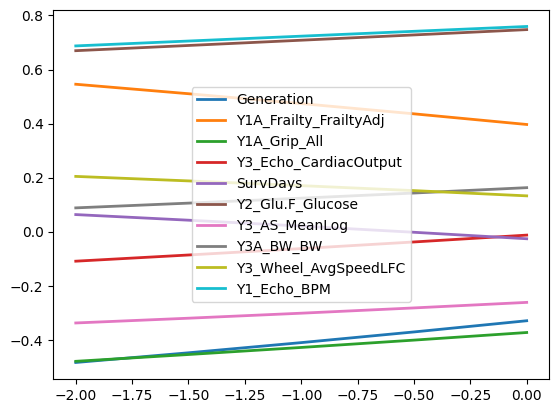

In [182]:
for col_name in difference_lv5_0_ranked.head(10).index.tolist(): 
    plt.plot(
        lv_traversal_values_0, 
        reconstructions_standardized_df_0[col_name], 
        label=col_name, 
        linewidth=2
    )
    plt.legend()

# Doing analysis for LV5 traversal with conditional label 1

In [183]:
unstandardized_data_tensor_1 = reconstructions_standardized_1 * col_std_tensor
unstandardized_data_tensor_1 = unstandardized_data_tensor_1 + col_means_tensor

In [184]:
reconstructions_unstandardized_df_1 = pd.DataFrame(unstandardized_data_tensor_1.cpu(), columns=all_input_features)
reconstructions_unstandardized_df_1

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,22.278988,1139.114502,27.372034,32.450829,25.771318,163.798340,116.519089,116.721848,497.120209,518.034729,...,1.486220,1.319062,-0.385329,150.296967,173.428162,136.179657,0.266421,0.200031,0.258055,2.575986
1,22.256840,1140.044556,27.285000,32.402977,25.746357,163.351562,116.373100,116.538818,497.531921,517.880127,...,1.488242,1.316391,-0.364696,149.636719,173.333069,135.994186,0.265995,0.199842,0.257562,2.579250
2,22.234224,1140.928345,27.192209,32.353539,25.723061,162.883408,116.230644,116.373215,497.982483,517.725464,...,1.490486,1.313902,-0.343720,148.957214,173.232651,135.787384,0.265511,0.199641,0.257091,2.583279
3,22.211216,1141.758911,27.093441,32.302494,25.701696,162.393570,116.092285,116.226952,498.473633,517.570496,...,1.492961,1.311604,-0.322438,148.259064,173.126785,135.557907,0.264963,0.199427,0.256644,2.588114
4,22.187920,1142.529053,26.988506,32.249844,25.682564,161.882004,115.958656,116.102036,499.006989,517.415039,...,1.495674,1.309501,-0.300899,147.543213,173.015396,135.304504,0.264347,0.199199,0.256226,2.593792


In [185]:
reconstructions_standardized_df_1 = pd.DataFrame(reconstructions_standardized_1.cpu(), columns=all_input_features)
reconstructions_standardized_df_1

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,-1.243402,0.744265,0.262925,-0.047616,-0.700288,0.227720,-0.273157,-0.491552,-0.165288,0.342296,...,-0.175181,0.017062,0.549114,-0.927713,0.132567,0.228937,1.480850,0.113441,-0.359937,-0.176432
1,-1.253089,0.749535,0.244636,-0.053218,-0.702114,0.215426,-0.277077,-0.494124,-0.157206,0.339150,...,-0.173650,0.015326,0.559875,-0.943361,0.129957,0.225002,1.475387,0.109326,-0.363502,-0.174061
2,-1.262982,0.754542,0.225138,-0.059005,-0.703819,0.202544,-0.280902,-0.496450,-0.148362,0.336003,...,-0.171951,0.013708,0.570814,-0.959465,0.127202,0.220614,1.469173,0.104943,-0.366908,-0.171134
3,-1.273046,0.759248,0.204383,-0.064981,-0.705382,0.189066,-0.284617,-0.498505,-0.138721,0.332851,...,-0.170076,0.012214,0.581912,-0.976011,0.124296,0.215746,1.462146,0.100276,-0.370134,-0.167622
4,-1.283237,0.763612,0.182333,-0.071144,-0.706782,0.174989,-0.288206,-0.500259,-0.128251,0.329688,...,-0.168021,0.010847,0.593145,-0.992977,0.121239,0.210369,1.454241,0.095307,-0.373156,-0.163497


In [186]:
z_min = reconstructions_standardized_df_1.iloc[0]
z_max = reconstructions_standardized_df_1.iloc[-1]
difference_lv5_1 = np.abs(z_max - z_min)
difference_lv5_1_ranked = difference_lv5_1.sort_values(ascending=False)
difference_lv5_1_ranked.head(10)

Y1A_BW_BW                0.080592
Y1A_Grip_All             0.065264
Y2_CBC_Hgb               0.064021
Y2_Echo_CardiacOutput    0.061619
Y1_Glu.F_Glucose         0.052731
Y3_Wheel_AvgDistLFC      0.044031
Y3_Wheel_AvgSpeedLFC     0.041005
Generation               0.039835
Y1_Echo_BPM              0.037037
Y3_CBC_Hgb               0.036284
dtype: float32

# Doing analysis for LV5 traversal with conditional label 2

In [195]:
unstandardized_data_tensor_2 = reconstructions_standardized_2 * col_std_tensor
unstandardized_data_tensor_2 = unstandardized_data_tensor_2 + col_means_tensor

In [196]:
reconstructions_unstandardized_df_2 = pd.DataFrame(unstandardized_data_tensor_2.cpu(), columns=all_input_features)
reconstructions_unstandardized_df_2

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,22.809435,1106.770874,28.068726,33.951660,27.769779,170.641846,124.198013,126.225578,502.986115,522.832153,...,1.556823,1.371175,-0.705908,160.344360,174.957336,136.652695,0.253227,0.204116,0.271846,2.735486
1,22.818314,1106.564331,28.025116,33.967205,27.818521,170.531006,124.339943,126.339630,503.510834,522.795471,...,1.560556,1.367752,-0.700390,160.248627,174.961838,136.569519,0.252249,0.204059,0.271750,2.741570
2,22.828310,1106.274780,27.978098,33.983707,27.872013,170.415359,124.494385,126.479889,504.071594,522.758484,...,1.564487,1.364327,-0.695152,160.159149,174.966614,136.470383,0.251192,0.203993,0.271689,2.748338
3,22.839497,1105.894897,27.927418,34.001091,27.930559,170.294601,124.661560,126.648483,504.670013,522.720581,...,1.568617,1.360903,-0.690233,160.076080,174.971451,136.353394,0.250049,0.203919,0.271666,2.755828
4,22.851959,1105.417236,27.872805,34.019257,27.994461,170.168472,124.841591,126.847610,505.307587,522.681030,...,1.572945,1.357487,-0.685670,159.999588,174.976181,136.216553,0.248817,0.203834,0.271685,2.764072


In [197]:
reconstructions_standardized_df_2 = pd.DataFrame(reconstructions_standardized_2.cpu(), columns=all_input_features)
reconstructions_standardized_df_2

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,-1.011375,0.561011,0.409324,0.128077,-0.554065,0.416031,-0.066957,-0.358047,-0.050144,0.439902,...,-0.121711,0.050938,0.381930,-0.689588,0.174533,0.238973,1.311581,0.202460,-0.260236,-0.060565
1,-1.007491,0.559841,0.400161,0.129897,-0.550499,0.412981,-0.063146,-0.356445,-0.039844,0.439156,...,-0.118883,0.048713,0.384808,-0.691857,0.174656,0.237209,1.299041,0.201216,-0.260926,-0.056146
2,-1.003119,0.558201,0.390281,0.131828,-0.546585,0.409798,-0.058999,-0.354475,-0.028836,0.438403,...,-0.115906,0.046486,0.387539,-0.693978,0.174787,0.235105,1.285475,0.199795,-0.261368,-0.051229
3,-0.998225,0.556048,0.379631,0.133863,-0.542301,0.406476,-0.054510,-0.352106,-0.017089,0.437631,...,-0.112778,0.044261,0.390104,-0.695947,0.174920,0.232623,1.270821,0.198171,-0.261534,-0.045788
4,-0.992774,0.553342,0.368155,0.135990,-0.537626,0.403005,-0.049675,-0.349309,-0.004574,0.436827,...,-0.109501,0.042041,0.392484,-0.697759,0.175050,0.229720,1.255011,0.196318,-0.261394,-0.039799


In [198]:
z_min = reconstructions_standardized_df_2.iloc[0]
z_max = reconstructions_standardized_df_2.iloc[-1]
difference_lv5_2 = np.abs(z_max - z_min)
difference_lv5_2_ranked = difference_lv5_2.sort_values(ascending=False)
difference_lv5_2_ranked.head(10)

Y1A_Frailty_FrailtyAdj    0.056570
Y1_Echo_BPM               0.045569
Y1A_BW_BW                 0.041170
Y2_CBC_Hgb                0.025163
Y2_AS_MeanLog             0.025026
Diet_num                  0.020766
Y2_Wheel_AvgSpeedLFC      0.018604
Generation                0.018601
Y2_Glu.F_Glucose          0.017282
Y3A_BW_BW                 0.016439
dtype: float32

# Doing analysis for LV5 traversal with conditional label 3

In [214]:
unstandardized_data_tensor_3 = reconstructions_standardized_3 * col_std_tensor
unstandardized_data_tensor_3 = unstandardized_data_tensor_3 + col_means_tensor

In [215]:
reconstructions_unstandardized_df_3 = pd.DataFrame(unstandardized_data_tensor_3.cpu(), columns=all_input_features)
reconstructions_unstandardized_df_3

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,23.665096,1045.072388,28.927736,37.482281,33.264168,184.349350,142.293213,147.206039,525.660645,533.619080,...,1.799567,1.445029,-1.063948,169.720398,176.867981,135.461548,0.215873,0.215611,0.296339,3.150474
1,23.725100,1042.420410,28.927969,37.599354,33.465027,184.749084,142.939026,148.008347,526.569214,533.781494,...,1.806895,1.441719,-1.083313,170.447479,177.013840,135.361481,0.213613,0.215723,0.297237,3.165766
2,23.788445,1039.618286,28.927483,37.718971,33.675064,185.167084,143.598541,148.853333,527.493408,533.932617,...,1.814120,1.438131,-1.103914,171.209518,177.166626,135.239899,0.211249,0.215824,0.298208,3.181431
3,23.855263,1036.659302,28.926176,37.840973,33.894676,185.604065,144.270721,149.742935,528.431702,534.070374,...,1.821203,1.434241,-1.125798,172.006577,177.326447,135.094330,0.208776,0.215913,0.299257,3.197448
4,23.925692,1033.536377,28.923944,37.965172,34.124294,186.060776,144.954407,150.679153,529.382446,534.192383,...,1.828102,1.430024,-1.149010,172.838715,177.493378,134.922195,0.206193,0.215989,0.300390,3.213794


In [216]:
reconstructions_standardized_df_3 = pd.DataFrame(reconstructions_standardized_3.cpu(), columns=all_input_features)
reconstructions_standardized_df_3

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,-0.637094,0.211438,0.589833,0.541384,-0.152054,0.793216,0.418947,-0.063320,0.394944,0.659367,...,0.062130,0.098946,0.195209,-0.467375,0.226967,0.213701,0.832372,0.452998,-0.083161,0.240898
1,-0.610847,0.196412,0.589882,0.555089,-0.137357,0.804215,0.436289,-0.052050,0.412779,0.662671,...,0.067680,0.096795,0.185110,-0.450143,0.230970,0.211578,0.803381,0.455436,-0.076671,0.252007
2,-0.583139,0.180536,0.589779,0.569092,-0.121989,0.815717,0.453999,-0.040180,0.430921,0.665746,...,0.073152,0.094462,0.174367,-0.432083,0.235163,0.208999,0.773050,0.457645,-0.069651,0.263387
3,-0.553912,0.163771,0.589505,0.583374,-0.105921,0.827742,0.472049,-0.027683,0.449339,0.668548,...,0.078517,0.091933,0.162954,-0.413192,0.239549,0.205910,0.741333,0.459593,-0.062065,0.275022
4,-0.523105,0.146077,0.589036,0.597913,-0.089120,0.840309,0.490407,-0.014531,0.468002,0.671030,...,0.083742,0.089192,0.150849,-0.393470,0.244130,0.202258,0.708185,0.461246,-0.053876,0.286897


In [217]:
z_min = reconstructions_standardized_df_3.iloc[0]
z_max = reconstructions_standardized_df_3.iloc[-1]
difference_lv5_3 = np.abs(z_max - z_min)
difference_lv5_3_ranked = difference_lv5_3.sort_values(ascending=False)
difference_lv5_3_ranked.head(10)

Y1A_Frailty_FrailtyAdj    0.124187
Generation                0.113989
Y1A_Grip_All              0.073905
Y3_Echo_CardiacOutput     0.073783
Y1_Echo_BPM               0.073057
Y2_Glu.F_Glucose          0.071460
SurvDays                  0.065361
Y3A_BW_BW                 0.062933
Y2A_BW_BW                 0.056529
Y2_Echo_CardiacOutput     0.054164
dtype: float32

# Doing analysis for LV5 traversal with conditional label 4

In [218]:
unstandardized_data_tensor_4 = reconstructions_standardized_4 * col_std_tensor
unstandardized_data_tensor_4 = unstandardized_data_tensor_4 + col_means_tensor

In [219]:
reconstructions_unstandardized_df_4 = pd.DataFrame(unstandardized_data_tensor_4.cpu(), columns=all_input_features)
reconstructions_unstandardized_df_4

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,23.530212,1041.470825,28.973503,37.649662,34.582615,186.974686,141.993698,150.299118,526.372986,532.854675,...,1.788189,1.438644,-0.948468,161.810181,176.016922,131.737854,0.214990,0.218184,0.302175,3.139412
1,23.606754,1037.907837,28.974434,37.763012,34.830929,187.515884,142.590683,151.354904,527.135376,532.870789,...,1.792107,1.433928,-0.975732,162.655746,176.189011,131.413696,0.212384,0.218192,0.303676,3.153575
2,23.689365,1034.070435,28.975035,37.881550,35.094673,188.092941,143.215347,152.486282,527.924438,532.873169,...,1.795919,1.428813,-1.005457,163.574371,176.374451,131.056854,0.209600,0.218184,0.305306,3.168428
3,23.778255,1029.949097,28.975246,38.005344,35.374454,188.706894,143.868027,153.696121,528.740356,532.860596,...,1.799607,1.423280,-1.037723,164.567947,176.573608,130.665466,0.206633,0.218159,0.307069,3.183984
4,23.873590,1025.536133,28.974993,38.134434,35.670773,189.358459,144.548874,154.986633,529.583069,532.831787,...,1.803153,1.417312,-1.072589,165.637817,176.786774,130.237885,0.203477,0.218115,0.308971,3.200251


In [220]:
reconstructions_standardized_df_4 = pd.DataFrame(reconstructions_standardized_4.cpu(), columns=all_input_features)
reconstructions_standardized_df_4

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,-0.696094,0.191032,0.599450,0.560978,-0.055586,0.865456,0.410904,-0.019870,0.408927,0.643815,...,0.053513,0.094795,0.255433,-0.654848,0.203611,0.134698,0.821041,0.509075,-0.040970,0.232863
1,-0.662614,0.170845,0.599645,0.574247,-0.037417,0.880349,0.426935,-0.005038,0.423892,0.644142,...,0.056480,0.091730,0.241214,-0.634808,0.208334,0.127820,0.787610,0.509261,-0.030116,0.243151
2,-0.626479,0.149103,0.599772,0.588124,-0.018120,0.896227,0.443709,0.010855,0.439382,0.644191,...,0.059367,0.088405,0.225713,-0.613037,0.213423,0.120249,0.751902,0.509088,-0.018334,0.253941
3,-0.587596,0.125752,0.599816,0.602616,0.002351,0.913121,0.461235,0.027850,0.455398,0.643935,...,0.062160,0.084809,0.208886,-0.589489,0.218889,0.111945,0.713837,0.508535,-0.005584,0.265241
4,-0.545895,0.100749,0.599763,0.617727,0.024032,0.931050,0.479518,0.045979,0.471940,0.643348,...,0.064846,0.080929,0.190703,-0.564133,0.224738,0.102873,0.673350,0.507584,0.008168,0.277058


In [221]:
z_min = reconstructions_standardized_df_4.iloc[0]
z_max = reconstructions_standardized_df_4.iloc[-1]
difference_lv5_4 = np.abs(z_max - z_min)
difference_lv5_4_ranked = difference_lv5_4.sort_values(ascending=False)
difference_lv5_4_ranked.head(10)

Generation                0.150199
Y1A_Frailty_FrailtyAdj    0.147692
Y1A_Grip_All              0.090716
SurvDays                  0.090284
Y3_Echo_CardiacOutput     0.089512
Y3A_BW_BW                 0.079618
Y3_AS_MeanLog             0.070445
Y2_Glu.F_Glucose          0.068614
Y2_Echo_CardiacOutput     0.068301
Y3_Wheel_AvgSpeedLFC      0.067060
dtype: float32

In [224]:
Counter(difference_lv5_4_ranked.head(10).index.to_list() + difference_lv5_3_ranked.head(10).index.to_list() + difference_lv5_2_ranked.head(10).index.to_list() + difference_lv5_1_ranked.head(10).index.to_list() + difference_lv5_0_ranked.head(10).index.to_list())

Counter({'Generation': 5,
         'Y1A_Frailty_FrailtyAdj': 4,
         'Y1A_Grip_All': 4,
         'Y3A_BW_BW': 4,
         'Y2_Glu.F_Glucose': 4,
         'Y1_Echo_BPM': 4,
         'SurvDays': 3,
         'Y3_Echo_CardiacOutput': 3,
         'Y2_Echo_CardiacOutput': 3,
         'Y3_Wheel_AvgSpeedLFC': 3,
         'Y3_AS_MeanLog': 2,
         'Y1A_BW_BW': 2,
         'Y2_CBC_Hgb': 2,
         'Y2A_BW_BW': 1,
         'Y2_AS_MeanLog': 1,
         'Diet_num': 1,
         'Y2_Wheel_AvgSpeedLFC': 1,
         'Y1_Glu.F_Glucose': 1,
         'Y3_Wheel_AvgDistLFC': 1,
         'Y3_CBC_Hgb': 1})

## Calculates the distances and combines timepoint variables

In [322]:
def calc_differences(reconstructions_standardized):
    cum_difference = np.abs(reconstructions_standardized.iloc[-1, [0, 1]] - reconstructions_standardized.iloc[0, [0, 1]])
    cum_difference = pd.concat([cum_difference, np.abs(reconstructions_standardized.iloc[-1, [-1]] - reconstructions_standardized.iloc[0, [-1]])])
    max_data = reconstructions_standardized.iloc[-1, 2:-1]
    min_data = reconstructions_standardized.iloc[0, 2:-1]
    feature_names = max_data.index.tolist()
    max_data_np = max_data.to_numpy()
    min_data_np = min_data.to_numpy()
    for feature in range(int(len(max_data) / 3)): 
        feature_name = feature_names[feature*3]
        feature_name = feature_name.split('_', 1)[1]
        max_vector = max_data_np[feature:feature+3]
        min_vector = min_data_np[feature:feature+3]
        diff = np.abs(max_vector-min_vector)
        #dist = np.linalg.norm(diff)
        dist = np.mean(diff, axis=0)
        cum_difference = pd.concat([cum_difference, pd.Series(data=dist, index=[feature_name])])
    return cum_difference

In [323]:
cum_difference_0 = calc_differences(reconstructions_standardized_df_0)
cum_difference_0.to_csv('/Users/racheliritani/Desktop/AD Project/mm-vae/feature_analysis/cum_difference_0_LV5.csv')
cum_difference_0.sort_values(ascending=False)

Generation            0.154423
SurvDays              0.089492
Echo_BPM              0.072779
CBC_Hgb               0.070969
Grip_All              0.070260
Frailty_FrailtyAdj    0.069732
Echo_CardiacOutput    0.068847
Glu.F_Glucose         0.067402
Wheel_AvgDistLFC      0.061613
AS_MeanLog            0.049746
Diet_num              0.047973
BW_BW                 0.047854
Rotarod_Mean          0.047229
Wheel_AvgSpeedLFC     0.040417
dtype: float32

In [324]:
cum_difference_1 = calc_differences(reconstructions_standardized_df_1)
cum_difference_1.to_csv('/Users/racheliritani/Desktop/AD Project/mm-vae/feature_analysis/cum_difference_1_LV5.csv')
cum_difference_1.sort_values(ascending=False)

Generation            0.039835
BW_BW                 0.036871
Wheel_AvgDistLFC      0.030837
Grip_All              0.030701
Frailty_FrailtyAdj    0.029613
Glu.F_Glucose         0.027584
Echo_CardiacOutput    0.025496
Echo_BPM              0.024758
AS_MeanLog            0.023970
CBC_Hgb               0.020264
Rotarod_Mean          0.019450
SurvDays              0.019347
Wheel_AvgSpeedLFC     0.014500
Diet_num              0.012935
dtype: float32

In [325]:
cum_difference_2 = calc_differences(reconstructions_standardized_df_2)
cum_difference_2.to_csv('/Users/racheliritani/Desktop/AD Project/mm-vae/feature_analysis/cum_difference_2_LV5.csv')
cum_difference_2.sort_values(ascending=False)

CBC_Hgb               0.023863
BW_BW                 0.021841
Diet_num              0.020766
Rotarod_Mean          0.019128
Generation            0.018601
AS_MeanLog            0.017408
Echo_BPM              0.015582
Echo_CardiacOutput    0.013015
Grip_All              0.012932
Glu.F_Glucose         0.012459
Wheel_AvgDistLFC      0.010549
Frailty_FrailtyAdj    0.009745
SurvDays              0.007669
Wheel_AvgSpeedLFC     0.007095
dtype: float32

In [326]:
cum_difference_3 = calc_differences(reconstructions_standardized_df_3)
cum_difference_3.to_csv('/Users/racheliritani/Desktop/AD Project/mm-vae/feature_analysis/cum_difference_3_LV5.csv')
cum_difference_3.sort_values(ascending=False)

Generation            0.113989
SurvDays              0.065361
CBC_Hgb               0.064436
Echo_BPM              0.060496
Grip_All              0.057182
Echo_CardiacOutput    0.055781
Glu.F_Glucose         0.055519
Frailty_FrailtyAdj    0.052289
Wheel_AvgDistLFC      0.050240
Diet_num              0.045999
AS_MeanLog            0.045892
Rotarod_Mean          0.044503
BW_BW                 0.040086
Wheel_AvgSpeedLFC     0.036073
dtype: float32

In [327]:
cum_difference_4 = calc_differences(reconstructions_standardized_df_4)
cum_difference_4.to_csv('/Users/racheliritani/Desktop/AD Project/mm-vae/feature_analysis/cum_difference_4_LV5.csv')
cum_difference_4.sort_values(ascending=False)

Generation            0.150199
SurvDays              0.090284
Echo_BPM              0.071275
Frailty_FrailtyAdj    0.069797
Glu.F_Glucose         0.067320
Echo_CardiacOutput    0.066685
CBC_Hgb               0.065825
Grip_All              0.062133
Wheel_AvgDistLFC      0.052765
BW_BW                 0.045560
Diet_num              0.044196
Rotarod_Mean          0.043109
AS_MeanLog            0.041629
Wheel_AvgSpeedLFC     0.030154
dtype: float32